In [79]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [80]:
df = pd.read_csv('/kaggle/input/datasets/nastya1998t/avito-data/Samara_flat_data12.csv')
df.head()

,Unnamed: 0,id,Цена,Цена за кв.метр,Количество собственников,Район,Улица,Вид сделки,Количество комнат,Общая площадь,Площадь кухни,Жилая площадь,Этаж,Этажей в доме,Балкон или лоджия,Высота потолков,Санузел,Окна,Ремонт,Техника,Способ продажи,Тип дома,Год постройки,Пассажирский лифт,Грузовой лифт,В доме,Двор,Парковка,Дополнительно,Тип комнат,Мебель,Тип продавца,Data_added,latitude,longitude,center_distance,metro_distance
0,0,7369217589,9350000.0,110000.0,1 собственник,Kirovsky,"18-й километр, 37",возможна ипотека,3,85.0,17.5,NaN,25.0,25.0,балкон,NaN,раздельный,NaN,дизайнерский,NaN,свободная,монолитный,2021.0,1,2,NaN,"детская площадка, спортивная площадка",открытая во дворе,панорамные окна,изолированные,"кухня, хранение одежды, спальные места",агентство,2025-05-27,NaN,NaN,NaN,NaN
1,1,7373532517,8200000.0,197590.0,1 собственник,Oktyabrsky,"Московское ш., 29",NaN,студия,41.5,NaN,41.5,17.0,24.0,балкон,2.7,совмещенный,"во двор, на солнечную сторону",дизайнерский,"кондиционер, холодильник, стиральная машина",свободная,монолитный,NaN,3,3,NaN,"детская площадка, спортивная площадка",подземная,гардеробная,NaN,"кухня, хранение одежды, спальные места",частное лицо,2025-05-27,53.218473,50.191275,7.14,2.04
2,4,4962057121,11200000.0,129032.0,2 собственника или больше,Zheleznodorozhny,"Революционная ул., 146А",NaN,3,86.8,12.1,47.5,1.0,11.0,лоджия,2.7,раздельный,"во двор, на солнечную сторону",евро,NaN,свободная,кирпичный,2000.0,1,1,газ,"детская площадка, спортивная площадка","подземная, открытая во дворе",NaN,изолированные,"кухня, хранение одежды",частное лицо,2025-05-27,53.195040,50.181259,5.80,0.64
3,5,7277003594,7400000.0,208451.0,1 собственник,Oktyabrsky,"ул. Осипенко, 2Б",возможна ипотека,1,35.5,7.6,18.8,1.0,16.0,лоджия,2.7,совмещенный,во двор,косметический,"холодильник, стиральная машина",свободная,кирпичный,1977.0,1,1,"мусоропровод, газ","детская площадка, спортивная площадка",открытая во дворе,NaN,NaN,"кухня, хранение одежды, спальные места",агентство,2025-05-27,53.214430,50.131862,3.59,0.58
4,6,4485182305,4999000.0,89428.0,2 собственника или больше,Promyshlenny,"Воронежская ул., 188",NaN,3,55.9,6.0,35.0,1.0,5.0,NaN,NaN,раздельный,NaN,косметический,NaN,свободная,кирпичный,NaN,нет,нет,NaN,NaN,NaN,NaN,изолированные,"кухня, хранение одежды, спальные места",агентство,2025-05-27,53.238580,50.222773,10.06,3.35


## Переименовываем колонки

In [81]:
df = df.rename(
            columns={
                "URL": "url",
                "Цена": "price",
                "Цена за кв.метр": "price_per_sqm",
                "Количество собственников": "number_of_owners",
                "Район": "district",
                "Улица": "street",
                "Вид сделки": "deal_type",
                "Количество комнат": "number_of_rooms",
                "Общая площадь": "total_area",
                "Площадь кухни": "kitchen_area",
                "Жилая площадь": "living_area",
                "Этаж": "floor",
                "Этажей в доме": "floors_in_building",
                "Балкон или лоджия": "balcony_or_loggia",
                "Высота потолков": "ceiling_height",
                "Санузел": "bathroom",
                "Окна": "windows",
                "Ремонт": "renovation",
                "Техника": "appliances",
                "Способ продажи": "sale_method",
                "Тип дома": "building_type",
                "Год постройки": "year_built",
                "Пассажирский лифт": "passenger_elevator",
                "Грузовой лифт": "freight_elevator",
                "В доме": "in_building",
                "Двор": "courtyard",
                "Парковка": "parking",
                "Дополнительно": "additional_info",
                "Тип комнат": "room_type",
                "Мебель": "furniture",
                "Тип продавца": "seller_type",
                "Data_added": "data_added",
            }
        )

## EDA

### Первичный осмотр

In [82]:
df.shape

(5678, 37)

In [83]:
df.dtypes.value_counts()

object     22
float64    13
int64       2
Name: count, dtype: int64

In [84]:
# Исследуем количество пропусков
null_count = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100
null_values = pd.DataFrame({
    'column_name': df.columns,
    'null_count': null_count.values,
    'null_percentage': null_percentage.values
}).set_index('column_name').T
null_values

column_name,Unnamed: 0,id,price,price_per_sqm,number_of_owners,district,street,deal_type,number_of_rooms,total_area,kitchen_area,living_area,floor,floors_in_building,balcony_or_loggia,ceiling_height,bathroom,windows,renovation,appliances,sale_method,building_type,year_built,passenger_elevator,freight_elevator,in_building,courtyard,parking,additional_info,room_type,furniture,seller_type,data_added,latitude,longitude,center_distance,metro_distance
null_count,0.0,0.0,1.000000,0.0,0.0,728.000000,0.0,2075.000000,0.0,0.0,410.000000,1082.000000,0.0,0.0,1544.000000,2440.000000,697.000000,1555.000000,938.000000,3462.000000,511.000000,4.000000,2308.000000,1437.000000,1899.000000,3148.000000,1630.000000,1647.000000,4699.000000,2437.000000,2956.000000,0.0,0.0,763.00000,763.00000,449.000000,449.000000
null_percentage,0.0,0.0,0.017612,0.0,0.0,12.821416,0.0,36.544558,0.0,0.0,7.220852,19.056006,0.0,0.0,27.192673,42.972878,12.275449,27.386404,16.519901,60.972173,8.999648,0.070447,40.648116,25.308207,33.444875,55.442057,28.707291,29.006692,82.758013,42.920042,52.060585,0.0,0.0,13.43783,13.43783,7.907714,7.907714


In [85]:
#Сводная статистика по числовым характеристикам
numerical_features = df.select_dtypes(include=[np.number])
numerical_features.describe().round(3)

,Unnamed: 0,id,price,price_per_sqm,total_area,kitchen_area,living_area,floor,floors_in_building,ceiling_height,year_built,latitude,longitude,center_distance,metro_distance
count,5678.000,5.678000e+03,5.677000e+03,5678.000,5678.000,5268.000,4596.000,5678.000,5678.000,3238.000,3370.000,4915.000,4915.000,5229.000,5229.000
mean,1233.045,5.673618e+09,7.292827e+06,127322.858,55.408,11.487,30.209,6.196,11.356,11.102,1987.736,53.222,50.241,12.602,7.730
std,813.713,1.677224e+09,5.719497e+06,45734.104,34.462,7.457,15.569,5.002,6.996,123.665,97.814,0.108,1.727,110.608,110.381
min,0.000,1.848118e+08,8.000000e+05,5600.000,12.500,2.000,5.000,1.000,1.000,0.000,0.000,47.829,48.403,0.060,0.050
25%,553.000,4.342343e+09,4.150000e+06,99326.750,38.500,7.000,18.000,2.000,5.000,2.500,1972.000,53.197,50.148,5.470,1.210
50%,1114.000,4.978026e+09,5.799999e+06,118076.000,49.000,9.600,28.750,5.000,9.000,2.700,1992.000,53.218,50.198,8.260,2.730
75%,1823.750,7.326790e+09,8.400000e+06,145427.500,65.000,13.300,38.800,8.000,16.000,2.700,2015.000,53.245,50.241,11.670,5.830
max,2965.000,7.447733e+09,8.800000e+07,1110886.000,1327.000,84.000,240.000,30.000,37.000,2900.000,2025.000,54.425,131.225,5470.830,5458.680


In [86]:
#Сводная статистика по категориальным признакам
categorical_features = df.select_dtypes(include=[object])
categorical_features.describe()

,number_of_owners,district,street,deal_type,number_of_rooms,balcony_or_loggia,bathroom,windows,renovation,appliances,sale_method,building_type,passenger_elevator,freight_elevator,in_building,courtyard,parking,additional_info,room_type,furniture,seller_type,data_added
count,5678,4950,5678,3603,5678,4134,4981,4123,4740,2216,5167,5674,4241,3779,2530,4048,4031,979,3241,2722,5678,5678
unique,36,11,2987,4,10,3,3,7,4,31,4,6,5,5,7,7,15,3,3,7,2,8
top,1 собственник,Kirovsky,"ул. Олега Пешкова, стр. 9",возможна ипотека,1,лоджия,совмещенный,во двор,косметический,кондиционер,свободная,кирпичный,1,нет,газ,"детская площадка, спортивная площадка",открытая во дворе,гардеробная,изолированные,"кухня, хранение одежды, спальные места",агентство,2025-05-27
freq,2075,950,94,3582,2004,2256,3072,1487,2119,488,4492,2973,2391,2113,1791,1909,3111,636,2627,1367,3663,1558


### Поиск аномалий

#### Общая площадь

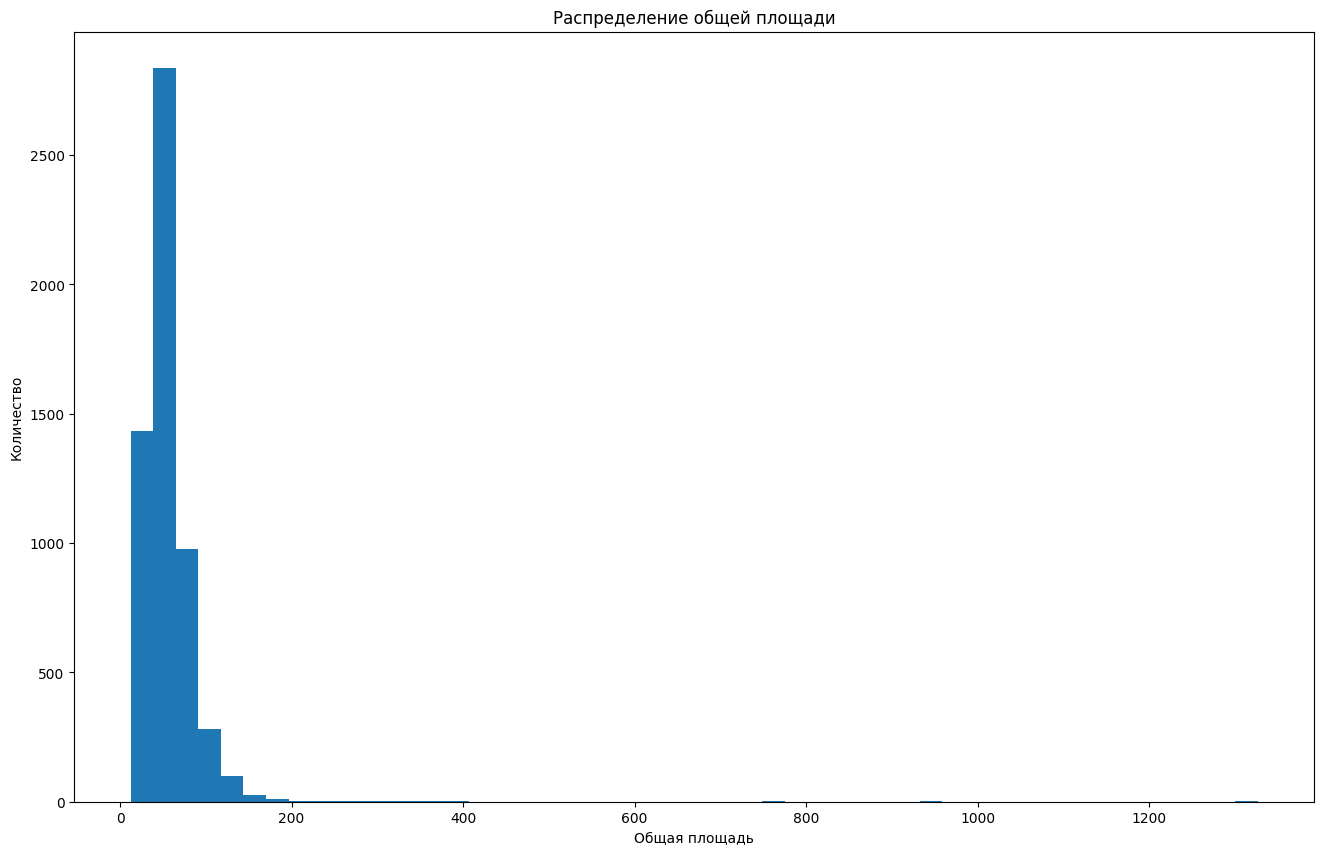

In [87]:
plt.figure(figsize=(16, 10))
plt.hist(df['total_area'], bins=50,)
plt.title('Распределение общей площади')
plt.xlabel('Общая площадь')
plt.ylabel('Количество')
plt.show()

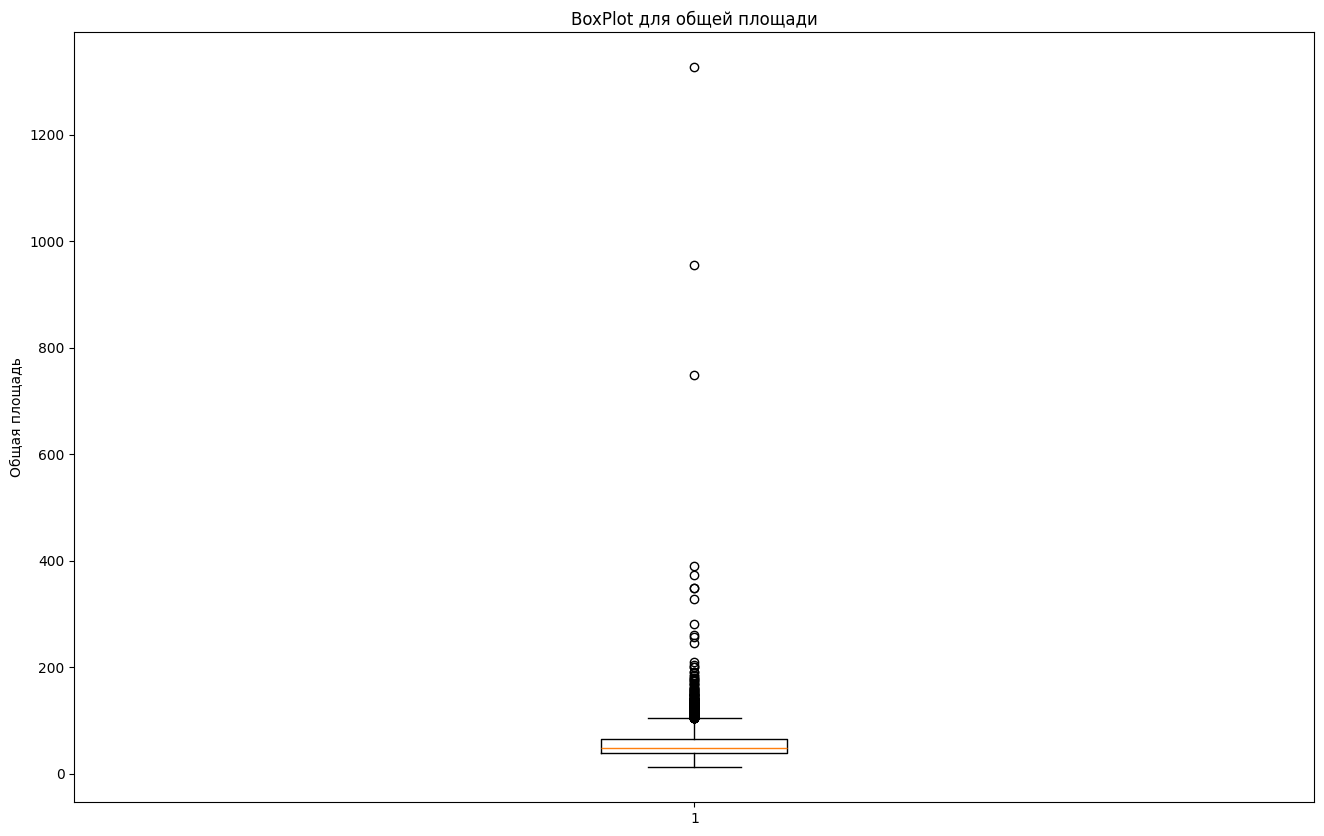

In [88]:
plt.figure(figsize=(16, 10))
plt.boxplot(df['total_area'])
plt.title('BoxPlot для общей площади')
plt.ylabel('Общая площадь')
plt.show()

In [89]:
total_area_outliers = df[(df['total_area'] > 600)]
total_area_outliers

,Unnamed: 0,id,price,price_per_sqm,number_of_owners,district,street,deal_type,number_of_rooms,total_area,kitchen_area,living_area,floor,floors_in_building,balcony_or_loggia,ceiling_height,bathroom,windows,renovation,appliances,sale_method,building_type,year_built,passenger_elevator,freight_elevator,in_building,courtyard,parking,additional_info,room_type,furniture,seller_type,data_added,latitude,longitude,center_distance,metro_distance
310,333,7293185341,4200000.0,5600.0,1 собственник,Promyshlenny,"ул. Победы, 102",возможна ипотека,3,750.0,8.0,69.2,3.0,4.0,балкон,3.0,раздельный,на улицу,требует ремонта,NaN,свободная,кирпичный,1941.0,нет,нет,газ,детская площадка,открытая во дворе,NaN,изолированные,NaN,агентство,2025-05-27,53.217332,50.257159,11.24,0.78
510,570,7418547988,6600000.0,6904.0,2 собственника или больше,NaN,"пр-т Масленникова, 15",продажа доли,3,956.0,12.0,90.0,3.0,4.0,балкон,2900.0,совмещенный,"во двор, на улицу, на солнечную сторону",дизайнерский,"кондиционер, холодильник, стиральная машина, п...",свободная,кирпичный,1958.0,нет,нет,газ,"закрытая территория, детская площадка, спортив...",открытая во дворе,NaN,изолированные,"кухня, хранение одежды, спальные места",частное лицо,2025-05-27,NaN,NaN,NaN,NaN
4435,868,7354454060,14990000.0,11296.0,1 собственник,Promyshlenny,"8-я просека, 60",возможна ипотека,3,1327.0,62.0,132.7,4.0,4.0,лоджия,2.8,совмещенный,на солнечную сторону,евро,"кондиционер, водонагреватель",свободная,кирпичный,2008.0,нет,нет,NaN,NaN,"подземная, открытая во дворе",гардеробная,изолированные,кухня,агентство,2025-05-07,53.262191,50.203005,10.72,6.28


In [90]:
df = df.drop([310, 510, 4435], axis=0)

#### Жилая площадь

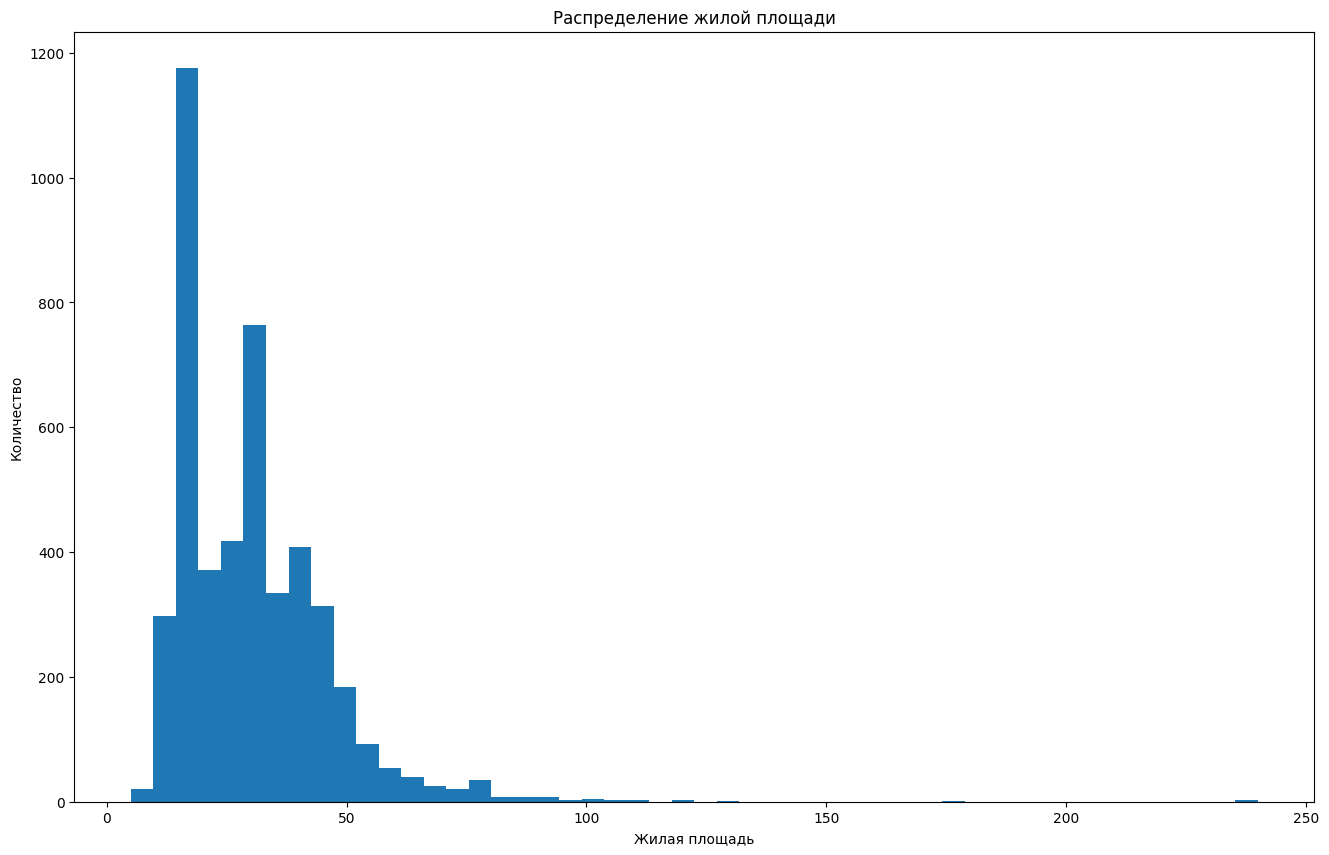

In [91]:
plt.figure(figsize=(16, 10))
plt.hist(df['living_area'], bins=50,)
plt.title('Распределение жилой площади')
plt.xlabel('Жилая площадь')
plt.ylabel('Количество')
plt.show()

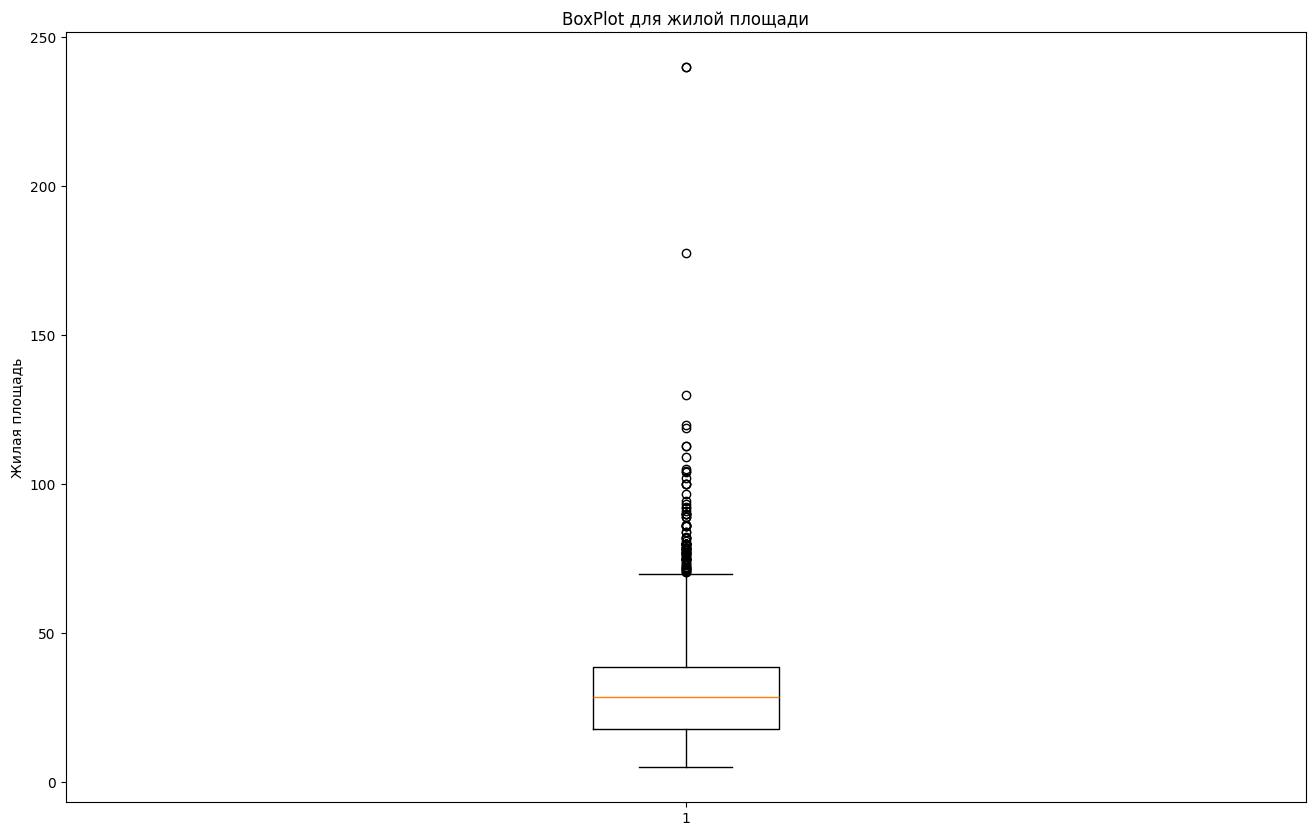

In [92]:
plt.figure(figsize=(16, 10))
plt.boxplot(df['living_area'].dropna())
plt.title('BoxPlot для жилой площади')
plt.ylabel('Жилая площадь')
plt.show()

In [93]:
living_area_outliers = df[(df['living_area'] > 150)]
living_area_outliers

,Unnamed: 0,id,price,price_per_sqm,number_of_owners,district,street,deal_type,number_of_rooms,total_area,kitchen_area,living_area,floor,floors_in_building,balcony_or_loggia,ceiling_height,bathroom,windows,renovation,appliances,sale_method,building_type,year_built,passenger_elevator,freight_elevator,in_building,courtyard,parking,additional_info,room_type,furniture,seller_type,data_added,latitude,longitude,center_distance,metro_distance
4883,2239,7233736484,65000000.0,185714.0,Контактное лицо,Oktyabrsky,"3-я просека, 176",NaN,6,350.0,20.0,240.0,3.0,3.0,NaN,NaN,"совмещенный, раздельный",NaN,дизайнерский,NaN,свободная,кирпичный,NaN,NaN,NaN,NaN,NaN,NaN,NaN,изолированные,NaN,агентство,2025-05-07,53.241250,50.170181,7.52,3.55
4896,2259,7329521302,45000000.0,174757.0,Контактное лицо,Krasnoglinsky,"Лесная ул., 5",NaN,4,257.5,17.0,177.7,14.0,15.0,лоджия,NaN,"совмещенный, раздельный",NaN,требует ремонта,NaN,свободная,кирпичный,NaN,NaN,NaN,NaN,NaN,NaN,NaN,изолированные,NaN,агентство,2025-05-07,53.209540,50.122265,2.76,0.80
5288,2828,2220700161,65000000.0,185714.0,Авито — сайт объявлений России. © ООО «КЕХ еКо...,Oktyabrsky,"3-я просека, 169",NaN,7,350.0,60.0,240.0,3.0,3.0,NaN,6.0,раздельный,NaN,дизайнерский,"кондиционер, холодильник, стиральная машина, п...",свободная,монолитно-кирпичный,2019.0,NaN,NaN,газ,"закрытая территория, детская площадка",подземная,"гардеробная, панорамные окна",изолированные,"кухня, хранение одежды, спальные места",частное лицо,2025-05-07,53.241395,50.168411,7.45,3.52


#### Площадь кухни

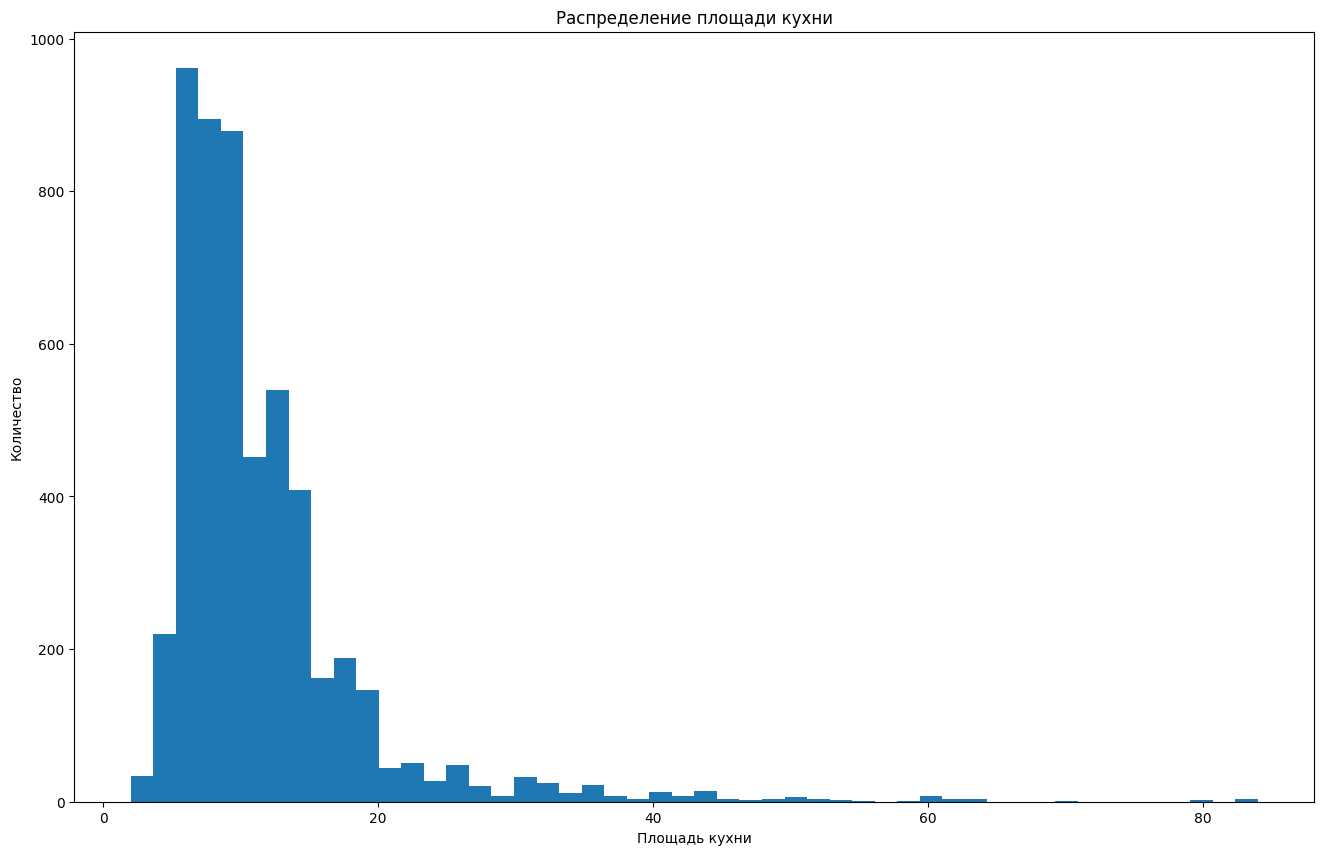

In [94]:
plt.figure(figsize=(16, 10))
plt.hist(df['kitchen_area'], bins=50,)
plt.title('Распределение площади кухни')
plt.xlabel('Площадь кухни')
plt.ylabel('Количество')
plt.show()

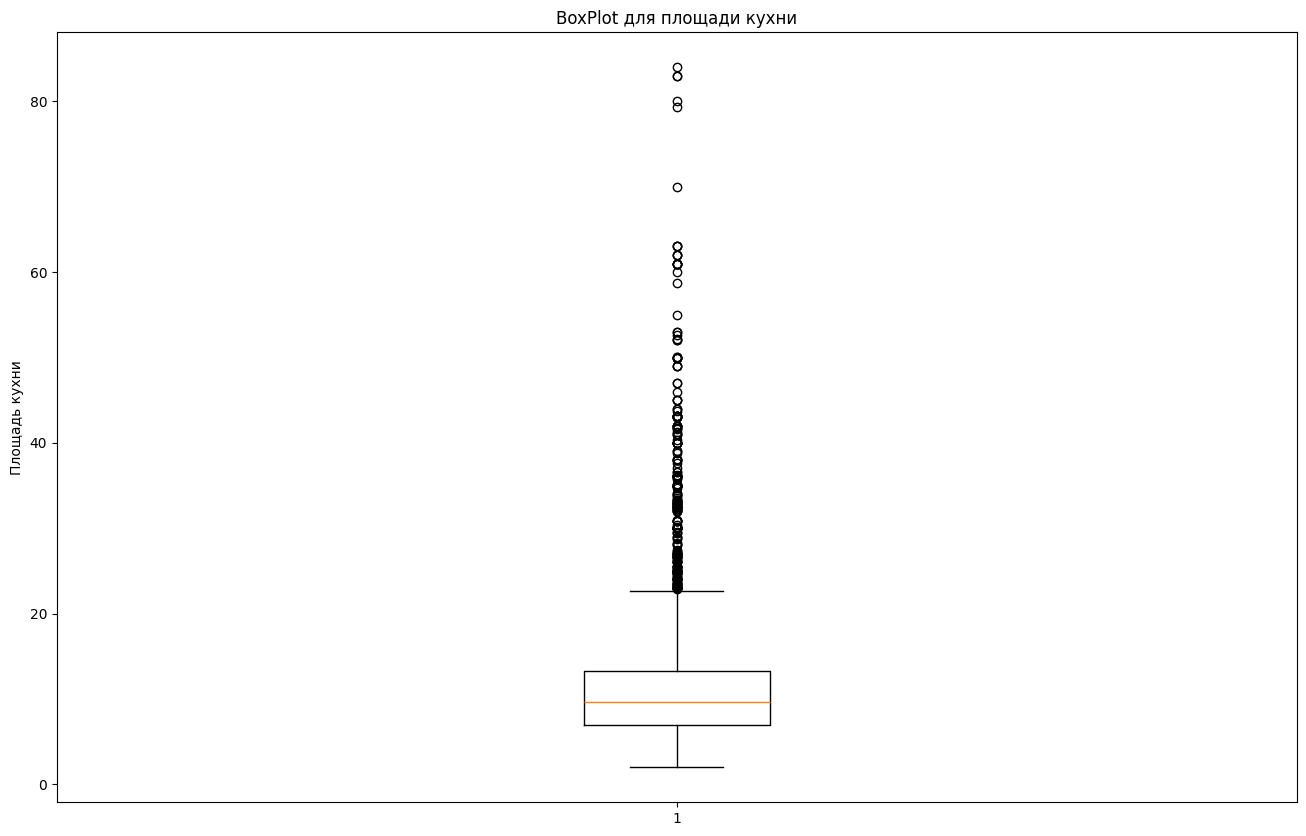

In [95]:
plt.figure(figsize=(16, 10))
plt.boxplot(df['kitchen_area'].dropna())
plt.title('BoxPlot для площади кухни')
plt.ylabel('Площадь кухни')
plt.show()

#### Высота потолков

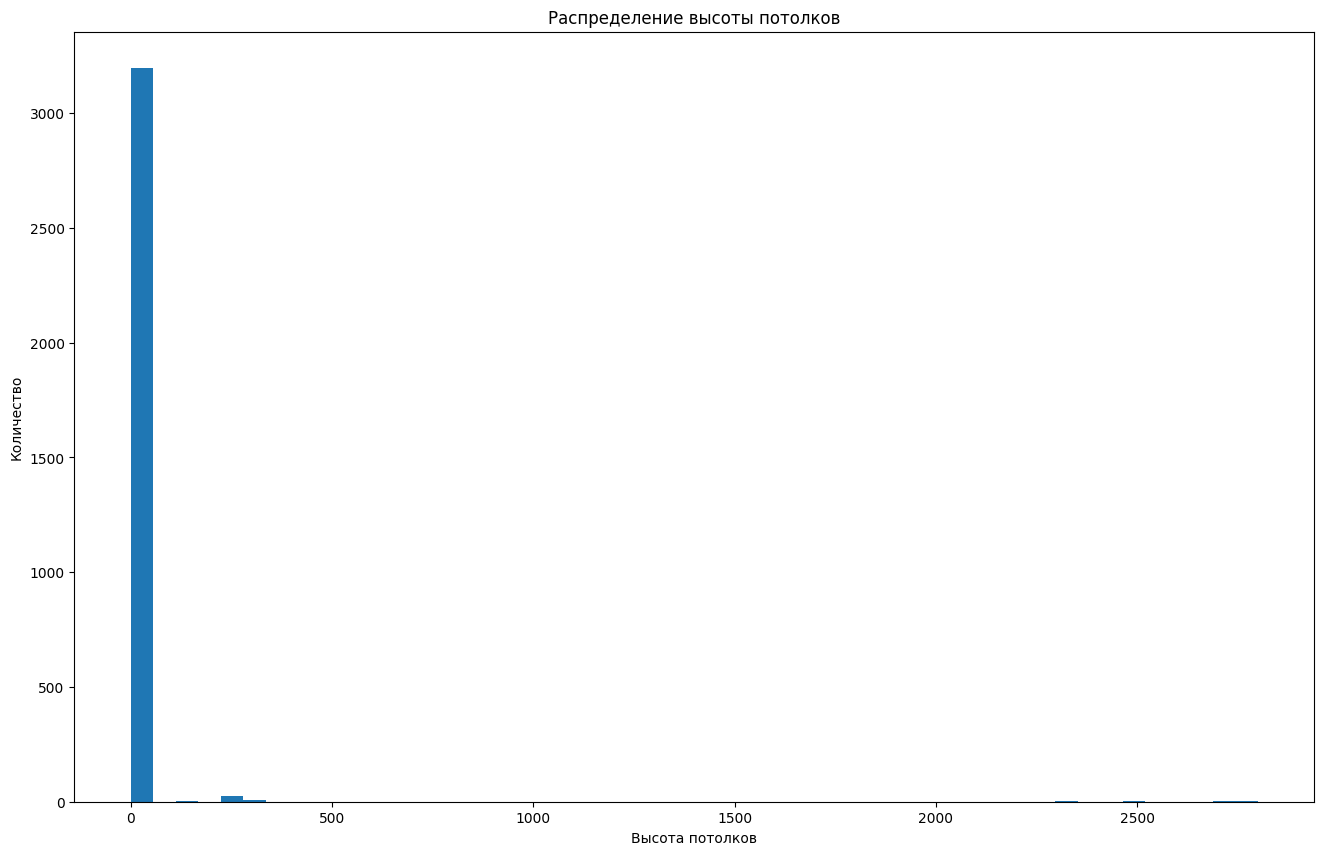

In [96]:
plt.figure(figsize=(16, 10))
plt.hist(df['ceiling_height'], bins=50,)
plt.title('Распределение высоты потолков')
plt.xlabel('Высота потолков')
plt.ylabel('Количество')
plt.show()

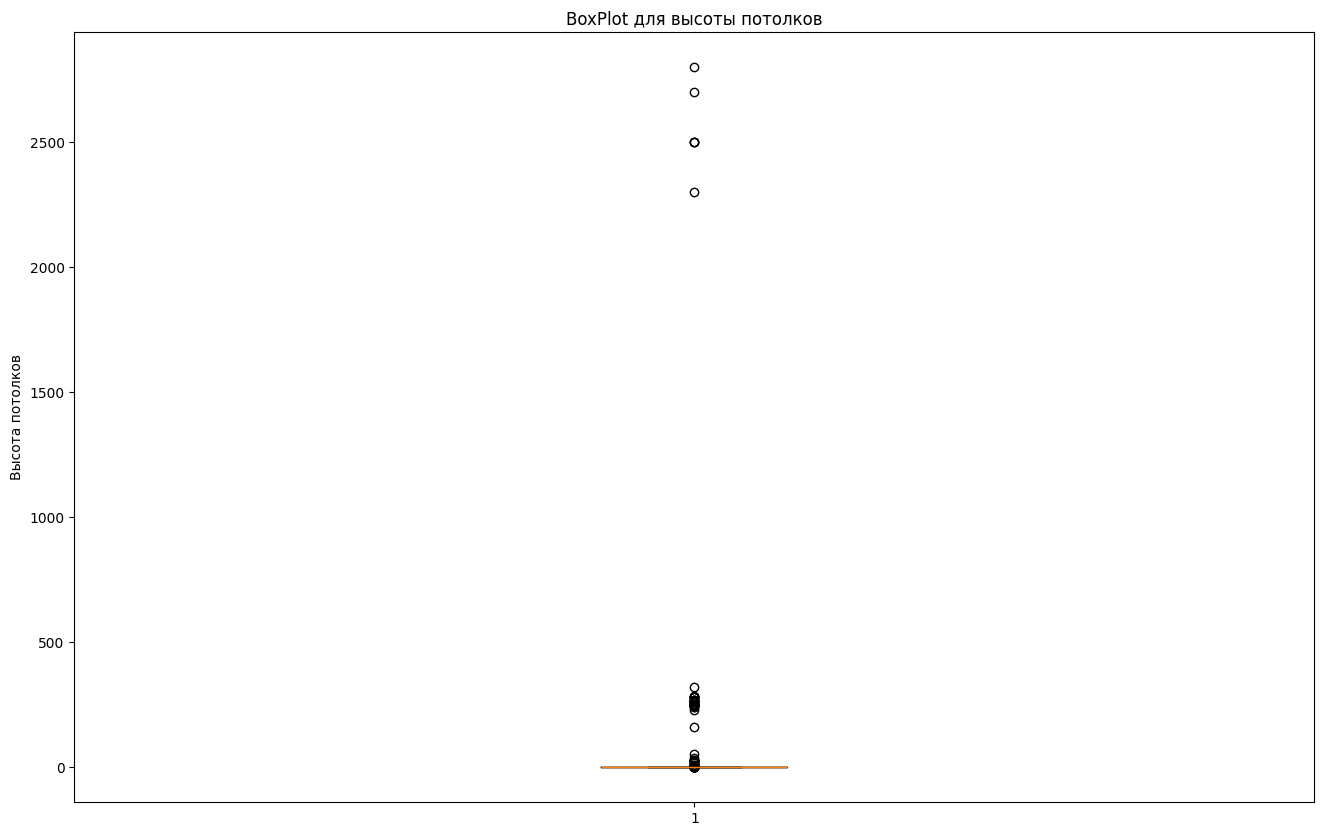

In [97]:
plt.figure(figsize=(16, 10))
plt.boxplot(df['ceiling_height'].dropna())
plt.title('BoxPlot для высоты потолков')
plt.ylabel('Высота потолков')
plt.show()

In [98]:
def normalize_ceiling_height(df):
    """
    Преобразует значения в столбце 'ceiling_height' так, чтобы первая цифра числа
    стала целой частью, а все остальные - дробной частью.
    Например: 2700.0 -> 2.7, 280.0 -> 2.8, 28.0 -> 2.8
    """
    def _convert_value(x):
        if x == 0:
            return 0.0
        try:
            # Преобразуем число в строку и удаляем точку (если это float)
            s = str(x).replace('.', '')
            # Первая цифра - целая часть, остальные - дробная
            if len(s) > 1:
                return float(f"{s[0]}.{s[1:]}")
            else:
                return float(s[0])
        except:
            return x
    
    df['ceiling_height'] = df['ceiling_height'].apply(_convert_value)
    return df

In [99]:
df = normalize_ceiling_height(df)

In [100]:
df.describe().round(3)

,Unnamed: 0,id,price,price_per_sqm,total_area,kitchen_area,living_area,floor,floors_in_building,ceiling_height,year_built,latitude,longitude,center_distance,metro_distance
count,5675.000,5.675000e+03,5.674000e+03,5675.000,5675.000,5265.000,4593.000,5675.000,5675.000,3235.000,3367.000,4913.000,4913.000,5227.000,5227.000
mean,1233.385,5.672729e+09,7.292138e+06,127385.971,54.903,11.478,30.165,6.198,11.360,2.691,1987.752,53.222,50.241,12.603,7.732
std,813.779,1.677221e+09,5.719941e+06,45663.668,25.981,7.427,15.464,5.003,6.996,0.302,97.853,0.108,1.728,110.629,110.403
min,0.000,1.848118e+08,8.000000e+05,13762.000,12.500,2.000,5.000,1.000,1.000,0.000,0.000,47.829,48.403,0.060,0.050
25%,553.000,4.342047e+09,4.150000e+06,99338.000,38.500,7.000,18.000,2.000,5.000,2.500,1972.000,53.197,50.148,5.470,1.210
50%,1115.000,4.977734e+09,5.799999e+06,118092.000,49.000,9.600,28.700,5.000,9.000,2.700,1992.000,53.218,50.198,8.260,2.730
75%,1824.500,7.326788e+09,8.400000e+06,145473.500,65.000,13.300,38.800,8.000,16.000,2.700,2015.000,53.245,50.241,11.675,5.825
max,2965.000,7.447733e+09,8.800000e+07,1110886.000,391.000,84.000,240.000,30.000,37.000,9.100,2025.000,54.425,131.225,5470.830,5458.680


## Исследуем зависимую переменную

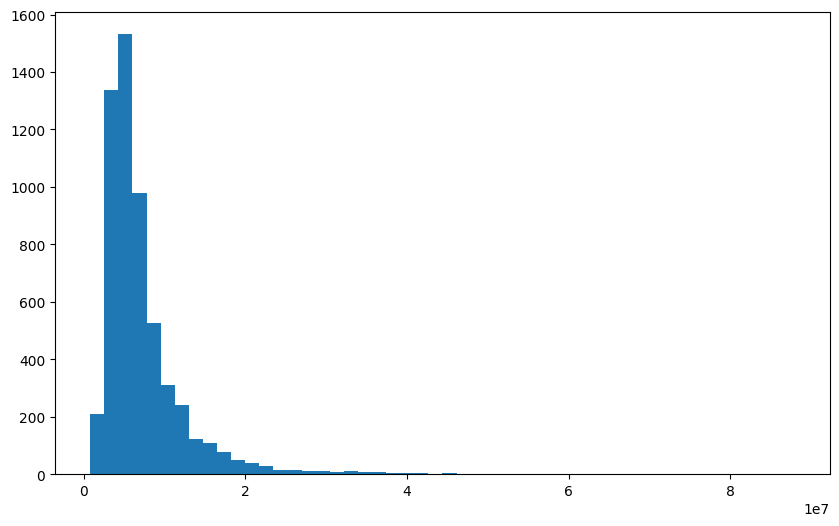

In [101]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50,)
plt.show()

correlation = df.corr()['price'].sort_values(ascending=False)
print(correlation)

## Обработка колонок
### Модификация фичей и заполнение пропусков

In [102]:
null_count = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100
null_values = pd.DataFrame({
    'column_name': df.columns,
    'null_count': null_count.values,
    'null_percentage': null_percentage.values
}).set_index('column_name').T
null_values

column_name,Unnamed: 0,id,price,price_per_sqm,number_of_owners,district,street,deal_type,number_of_rooms,total_area,kitchen_area,living_area,floor,floors_in_building,balcony_or_loggia,ceiling_height,bathroom,windows,renovation,appliances,sale_method,building_type,year_built,passenger_elevator,freight_elevator,in_building,courtyard,parking,additional_info,room_type,furniture,seller_type,data_added,latitude,longitude,center_distance,metro_distance
null_count,0.0,0.0,1.000000,0.0,0.0,727.000000,0.0,2075.000000,0.0,0.0,410.00000,1082.000000,0.0,0.0,1544.000000,2440.000000,697.000000,1555.000000,938.000000,3461.000000,511.000000,4.000000,2308.000000,1437.000000,1899.000000,3147.000000,1629.000000,1647.000000,4697.00000,2437.000000,2955.000000,0.0,0.0,762.000000,762.000000,448.000000,448.000000
null_percentage,0.0,0.0,0.017621,0.0,0.0,12.810573,0.0,36.563877,0.0,0.0,7.22467,19.066079,0.0,0.0,27.207048,42.995595,12.281938,27.400881,16.528634,60.986784,9.004405,0.070485,40.669604,25.321586,33.462555,55.453744,28.704846,29.022026,82.76652,42.942731,52.070485,0.0,0.0,13.427313,13.427313,7.894273,7.894273


#### one_hot_encoding

In [103]:
# Функция для one_hot_encoding колонок со списками
def one_hot_encoding(column_name):
    values_list = df[column_name].dropna()
    el_list = []
    for val in values_list:
        val_el = val.split(', ')
        for el in val_el:
            if el not in el_list:
                el_list.append(el)
    for el_l in el_list:
        df[el_l] = df[column_name].str.contains(el_l, case=False, na=False).astype(int)

#### Количество собственников

In [104]:
df['number_of_owners'].nunique()

36

In [105]:
df['number_of_owners'].unique().tolist()

['1 собственник',
 '2 собственника или больше',
 'Группа компаний «Новый ДОН»',
 'Группа компаний «Строительный холдинг Град»',
 'Контактное лицо',
 'Авито — сайт объявлений России. © ООО «КЕХ еКоммерц» 2007–2025. Правила Авито. Политика конфиденциальности. Оплачивая услуги на Авито, вы принимаете оферту. Авито использует рекомендательные технологии.',
 'Группа компаний «Владимир»',
 'ООО «СЗ «СПЕКТРСТРОЙ»',
 'Группа компаний «УК Альянс-Менеджмент»',
 'Группа компаний «Финстрой»',
 'Группа компаний «ВИРА»',
 'Группа компаний «Древо»',
 'Группа компаний «СтройКонтракт»',
 'Группа компаний «Корпорация КОШЕЛЕВ»',
 'Группа компаний «Развитие»',
 'ООО «СЗ «Архитектор»',
 'ООО «СЗ ПАРКОВЫЙ»',
 'ООО «Специализированный Застройщик «ГВ Девелопмент»',
 'ООО СЗ «ВОЛГА СТРОЙ ДЕВЕЛОПМЕНТ»',
 'Группа компаний «Амонд»',
 'ООО «Специализированный Застройщик «Ракита»',
 'Закажите бесплатный звонок',
 'Группа компаний «Новое Время»',
 'ООО «КОЛЬЦО»',
 'Группа компаний «Самарский хлебзавод №9»',
 'ООО «\

In [106]:
# Колонку "количество собственников" преобразуем в "собственник или застройщик"
df.loc[df['number_of_owners'].isin(['1 собственник', '2 собственника или больше', 'Контактное лицо']), 'owner_or_developer'] = 1
df['owner_or_developer'] = df['owner_or_developer'].fillna(0)
df['owner_or_developer'] = df['owner_or_developer'].astype(int)

#### Район

In [107]:
df['district'].nunique()

11

In [108]:
df['district'] = df['district'].fillna('unknown')

#### Вид сделки

In [109]:
df['deal_type'].value_counts()

deal_type
возможна ипотека             3580
продажа доли                   15
аукцион                         3
возможна ипотека, аукцион       2
Name: count, dtype: int64

In [110]:
df['deal_type'] = df['deal_type'].fillna('unknown')

#### Количество комнат

In [111]:
# Колонку "количество комнат" преобразуем в порядковый признак. Студии и квавртиры со свободной планировкой относим к однушкам
df.loc[df['number_of_rooms']=='студия', 'number_of_rooms'] = 1
df.loc[df['number_of_rooms']=='свободная планировка', 'number_of_rooms'] = 1
df['number_of_rooms'] = df['number_of_rooms'].astype(int)

#### Общая площадь

In [112]:
# Общая площадь сильно коррелирует с таргетом, поэтому удаляем строчки с пропущенными значениями
df = df.dropna(subset=['total_area'], axis=0)

#### Площадь кухни

In [113]:
# Заполняем пропущенные значения площади кухни на основе общей площади с помощью линеной регрессии

known_data = df[df['kitchen_area'].notna()]
unknown_data = df[df['kitchen_area'].isna()]

model = LinearRegression()
model.fit(known_data[['total_area']], known_data['kitchen_area'])
    
# Предсказываем пропущенные значения
predicted_values = model.predict(unknown_data[['total_area']])
    
# Заполняем пропущенные значения
df.loc[df['kitchen_area'].isna(), 'kitchen_area'] = predicted_values

#### Жилая площадь

In [114]:
# Заполняем пропущенные значения жилой площади на основе общей площади с помощью линеной регрессии

known_data = df[df['living_area'].notna()]
unknown_data = df[df['living_area'].isna()]

model = LinearRegression()
model.fit(known_data[['total_area']], known_data['living_area'])
    
# Предсказываем пропущенные значения
predicted_values = model.predict(unknown_data[['total_area']])
    
# Заполняем пропущенные значения
df.loc[df['living_area'].isna(), 'living_area'] = predicted_values

#### Балкон или лоджия

In [115]:
df['balcony_or_loggia'].value_counts()

balcony_or_loggia
лоджия            2255
балкон            1538
балкон, лоджия     338
Name: count, dtype: int64

In [116]:
# Применяем "one hot encoding" к колонке "балкон или лоджия"
df['loggia'] = df['balcony_or_loggia'].str.contains('лоджия', case=False, na=False).astype(int)
df['balcony'] = df['balcony_or_loggia'].str.contains('балкон', case=False, na=False).astype(int)

#### Высота потолков

In [117]:
# Заполняем пропущенные значения высоты потолков на основе типа здания
df["ceiling_height"] = (df["ceiling_height"].fillna(df.groupby("building_type")["ceiling_height"].transform("mean")))

#### Ванная комната

In [118]:
df['bathroom'].value_counts()

bathroom
совмещенный                3070
раздельный                 1774
совмещенный, раздельный     134
Name: count, dtype: int64

In [119]:
# Заполняем пропущенные значения ванной комнаты на основе количества комнат
df.loc[(df['bathroom'].isna()) & (df['number_of_rooms'].isin(['студия', '1', '2', 'свободная планировка'])), 'bathroom'] = 'совмещенный'
df['bathroom'] = df['bathroom'].fillna('раздельный')

#### Окна

In [120]:
df['windows'].value_counts()

windows
во двор                                    1487
на улицу                                    717
во двор, на улицу                           607
во двор, на улицу, на солнечную сторону     423
во двор, на солнечную сторону               422
на улицу, на солнечную сторону              319
на солнечную сторону                        145
Name: count, dtype: int64

In [121]:
# Применяем one_hot_encoding к колонке с окнами
one_hot_encoding('windows')

#### Ремонт

In [122]:
df['renovation'].value_counts()

renovation
косметический      2119
евро               1210
требует ремонта     837
дизайнерский        571
Name: count, dtype: int64

In [123]:
# Заполняем пропуски в колонке ремонт значением "unknown"
df['renovation'] = df['renovation'].fillna('unknown')

#### Техника

In [124]:
df['appliances'].value_counts()

appliances
кондиционер                                                                           488
холодильник, стиральная машина                                                        284
кондиционер, холодильник, стиральная машина                                           239
кондиционер, холодильник, стиральная машина, посудомоечная машина, водонагреватель    131
кондиционер, холодильник, стиральная машина, водонагреватель                          129
кондиционер, водонагреватель                                                          117
водонагреватель                                                                       100
холодильник                                                                            96
кондиционер, холодильник, стиральная машина, посудомоечная машина                      95
холодильник, стиральная машина, водонагреватель                                        73
кондиционер, холодильник                                                               67

In [125]:
# Преобразуем колонку с техникой в бинарную
df['appliances'] = df['appliances'].notna().astype(int)
df['appliances'].value_counts()

appliances
0    3461
1    2214
Name: count, dtype: int64

#### Способ продажи

In [126]:
df['sale_method'].value_counts()

sale_method
свободная                   4489
договор долевого участия     389
альтернативная               248
переуступка                   38
Name: count, dtype: int64

In [127]:
# Заполняем пропуски в колонке "способ продажи" значением "unknown"
df['sale_method'] = df['sale_method'].fillna('unknown')

#### Тип здания

In [128]:
df['building_type'].value_counts()

building_type
кирпичный              2970
панельный              1427
монолитный              738
монолитно-кирпичный     423
блочный                 105
деревянный                8
Name: count, dtype: int64

In [129]:
# Заполняем пропуски в колонке "тип здания" значением "unknown"
df['building_type'] = df['building_type'].fillna('unknown')

#### Год постройки

In [130]:
# # Заполняем пропуски в колонке "год постройки" средним
df['year_built'] = df['year_built'].fillna(df['year_built'].mean()).round().astype(int)

#### Пасажирский лифт

In [131]:
df['passenger_elevator'].value_counts()

passenger_elevator
1      2391
нет    1369
2       439
3        27
4        12
Name: count, dtype: int64

In [132]:
# Колонку "пасажирский лифт" преобразуем в порядковый признак
df.loc[df['passenger_elevator']=='нет', 'passenger_elevator'] = 0
df['passenger_elevator'] = df['passenger_elevator'].fillna(0)
df['passenger_elevator'] = df['passenger_elevator'].astype(int)

#### Грузовой лифт

In [133]:
df['freight_elevator'].value_counts()

freight_elevator
нет    2110
1      1439
2       205
3        14
4         8
Name: count, dtype: int64

In [134]:
# Колонку "грузовой лифт" преобразуем в порядковый признак
df.loc[df['freight_elevator']=='нет', 'freight_elevator'] = 0
df['freight_elevator'] = df['freight_elevator'].fillna(0)
df['freight_elevator'] = df['freight_elevator'].astype(int)

#### В доме

In [135]:
df['in_building'].value_counts()

in_building
газ                            1789
консьерж                        328
мусоропровод, газ               293
мусоропровод                     92
консьерж, газ                    14
консьерж, мусоропровод           11
консьерж, мусоропровод, газ       1
Name: count, dtype: int64

In [136]:
# Применяем "one hot encoding" к колонке "в доме"
df['gas'] = df['in_building'].str.contains('газ', case=False, na=False).astype(int)
df['concierge'] = df['in_building'].str.contains('консьерж', case=False, na=False).astype(int)
df['garbage_chute'] = df['in_building'].str.contains('мусоропровод', case=False, na=False).astype(int)

#### Двор

In [137]:
df['courtyard'].value_counts()

courtyard
детская площадка, спортивная площадка                         1909
детская площадка                                              1271
закрытая территория, детская площадка, спортивная площадка     532
закрытая территория, детская площадка                          178
закрытая территория                                            128
спортивная площадка                                             22
закрытая территория, спортивная площадка                         6
Name: count, dtype: int64

In [138]:
# Применяем "one hot encoding" к колонке "двор"
one_hot_encoding('courtyard')

#### Двор

In [139]:
df['parking'].value_counts()

parking
открытая во дворе                                                                3109
подземная                                                                         252
за шлагбаумом во дворе                                                            217
подземная, открытая во дворе                                                      150
открытая во дворе, за шлагбаумом во дворе                                         125
подземная, за шлагбаумом во дворе                                                  54
наземная многоуровневая, открытая во дворе                                         38
подземная, открытая во дворе, за шлагбаумом во дворе                               37
наземная многоуровневая                                                            11
подземная, наземная многоуровневая, открытая во дворе                              10
подземная, наземная многоуровневая, открытая во дворе, за шлагбаумом во дворе       9
наземная многоуровневая, открытая во дворе, за

#### Парковка

In [140]:
# Применяем "one hot encoding" к колонке "парковка"
one_hot_encoding('parking')

#### Дополнительно

In [141]:
df['additional_info'].value_counts()

additional_info
гардеробная                     635
панорамные окна                 178
гардеробная, панорамные окна    165
Name: count, dtype: int64

In [142]:
# Применяем "one hot encoding" к колонке "дополнительно"
one_hot_encoding('additional_info')

#### Тип комнат

In [143]:
df['room_type'].value_counts()

room_type
изолированные             2624
смежные                    350
изолированные, смежные     264
Name: count, dtype: int64

In [144]:
# Применяем "one hot encoding" к колонке "тип комнат"
one_hot_encoding('room_type')

#### Мебель

In [145]:
df['furniture'].value_counts()

furniture
кухня, хранение одежды, спальные места    1366
кухня, хранение одежды                     606
кухня                                      555
кухня, спальные места                      125
хранение одежды                             37
хранение одежды, спальные места             21
спальные места                              10
Name: count, dtype: int64

In [146]:
# Применяем "one hot encoding" к колонке "мебель"
one_hot_encoding('furniture')

#### Тип продавца

In [147]:
df['seller_type'].value_counts()

seller_type
агентство       3661
частное лицо    2014
Name: count, dtype: int64

In [148]:
# Преобразуем колонку с "тип продвца" в бинарную: 0-агентство, 1-частное лицо
df.loc[df['seller_type']=='агентство', 'seller_type'] = 0
df.loc[df['seller_type']=='частное лицо', 'seller_type'] = 1
df['seller_type'] = df['seller_type'].astype(int)

#### Создаем новые колонки

In [149]:
df['average_room_size'] = df['living_area'] / df['number_of_rooms']

In [150]:
df['room_density'] = df['total_area'] / df['number_of_rooms']

In [151]:
df['living_area_ratio'] = df['living_area'] / df['total_area']

In [152]:
df['kitchen_area_ratio'] = df['kitchen_area'] / df['total_area']

In [153]:
df['floor_ratio'] = df['floor'] / df['floors_in_building']

#### Создаем новый признак расстояние до центра города

In [154]:
# Загружаем координаты центра города
point1 = pd.read_json('/kaggle/input/datasets/nastya1998t/avito-data/center_coords.json')
point1 = (point1.loc[0,'latitude'], point1.loc[0,'longitude'])

In [155]:
# Cоздаем функцию по расчету расстояния до центра
def calculate_distance(row):
    if not(pd.isnull(row['latitude']) and pd.isnull(row['longitude'])): 
        point2 = (row['latitude'], row['longitude'])
        dist = geodesic(point1, point2).kilometers
        return round(dist,2)
    else:
        return None

In [156]:
# Расчитываем расстояние до центра города
df['center_distance'] = df.apply(calculate_distance, axis=1)

In [157]:
df = df.dropna(subset=['center_distance'], axis=0)

### Удаляем лишние колонки

In [158]:
df = df.drop(columns=['Unnamed: 0', 'id', 'price_per_sqm', 'data_added', 'street'])

In [159]:
df = df.drop(columns=['number_of_owners', 'deal_type', 'balcony_or_loggia', 'in_building', 'courtyard', 'year_built',
                     'parking', 'windows', 'additional_info', 'room_type', 'furniture', 'latitude', 'longitude'])

In [160]:
df = df.dropna(subset=['ceiling_height'], axis=0)

In [161]:
# Удаляем строчки с пропущенными значениями таргета
df = df.dropna(subset=['price'], axis=0)

In [162]:
# Преобразуем колонку с "цена" в вещественную
df['price'] = df['price'].astype(int)

In [163]:
null_count = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100
null_values = pd.DataFrame({
    'column_name': df.columns,
    'null_count': null_count.values,
    'null_percentage': null_percentage.values
}).set_index('column_name').T
null_values

column_name,price,district,number_of_rooms,total_area,kitchen_area,living_area,floor,floors_in_building,ceiling_height,bathroom,renovation,appliances,sale_method,building_type,passenger_elevator,freight_elevator,seller_type,center_distance,metro_distance,owner_or_developer,loggia,balcony,во двор,на солнечную сторону,на улицу,gas,concierge,garbage_chute,детская площадка,спортивная площадка,закрытая территория,открытая во дворе,подземная,за шлагбаумом во дворе,наземная многоуровневая,панорамные окна,гардеробная,изолированные,смежные,кухня,хранение одежды,спальные места,average_room_size,room_density,living_area_ratio,kitchen_area_ratio,floor_ratio
null_count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
null_percentage,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [164]:
df.dtypes.value_counts()

int64      29
float64    13
object      5
Name: count, dtype: int64

In [165]:
df['price'].dtype

dtype('int64')

### Удаляем выбросы в target

In [166]:
r = df['price'].quantile(0.75) - df['price'].quantile(0.25) 
upper_quantile = df['price'].quantile(0.75)+1.5 * r
df[df['price']>upper_quantile].shape
df = df[(df['price']<upper_quantile)]

### Обрабатываем категориальные признаки

In [167]:
categorical_columns = df.select_dtypes(include=[object])
categorical_columns.describe()

,district,bathroom,renovation,sale_method,building_type
count,4529,4529,4529,4529,4529
unique,12,3,5,5,7
top,Kirovsky,совмещенный,косметический,свободная,кирпичный
freq,775,2561,1897,3810,2408


In [168]:
%pip install category_encoders
from sklearn.preprocessing import OneHotEncoder
from category_encoders import TargetEncoder

for col in categorical_columns:
    
    # Для колонок с маленькой размерностью — OneHotEncoder
    if df[col].nunique() <= 10:
        # Создаем и применяем OneHotEncoder (drop_first=True для удаления первого уровня)
        encoder = OneHotEncoder(drop='first', sparse_output=False)
        encoded_data = encoder.fit_transform(df[[col]])
        
        # Получаем имена новых колонок
        new_columns = encoder.get_feature_names_out([col])
        
        # Создаем DataFrame с новыми колонками
        encoded_df = pd.DataFrame(encoded_data, columns=new_columns, index=df.index)
        
        # Удаляем исходную колонку и добавляем закодированные
        df = df.drop(col, axis=1)
        df = pd.concat([df, encoded_df], axis=1)
        
    # Для остальных — TargetEncoder
    else:
        encoder = TargetEncoder()
        df[col] = encoder.fit_transform(df[[col]], df['price'])

Note: you may need to restart the kernel to use updated packages.


In [169]:
df.dtypes.value_counts()

float64    30
int64      29
Name: count, dtype: int64

### Строим матрицу корреляций

In [170]:
mask = np.zeros_like(df.corr())
triangle_indices = np.triu_indices_from(mask)
mask[triangle_indices] = True
mask

array([[1., 1., 1., ..., 1., 1., 1.],
       [0., 1., 1., ..., 1., 1., 1.],
       [0., 0., 1., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

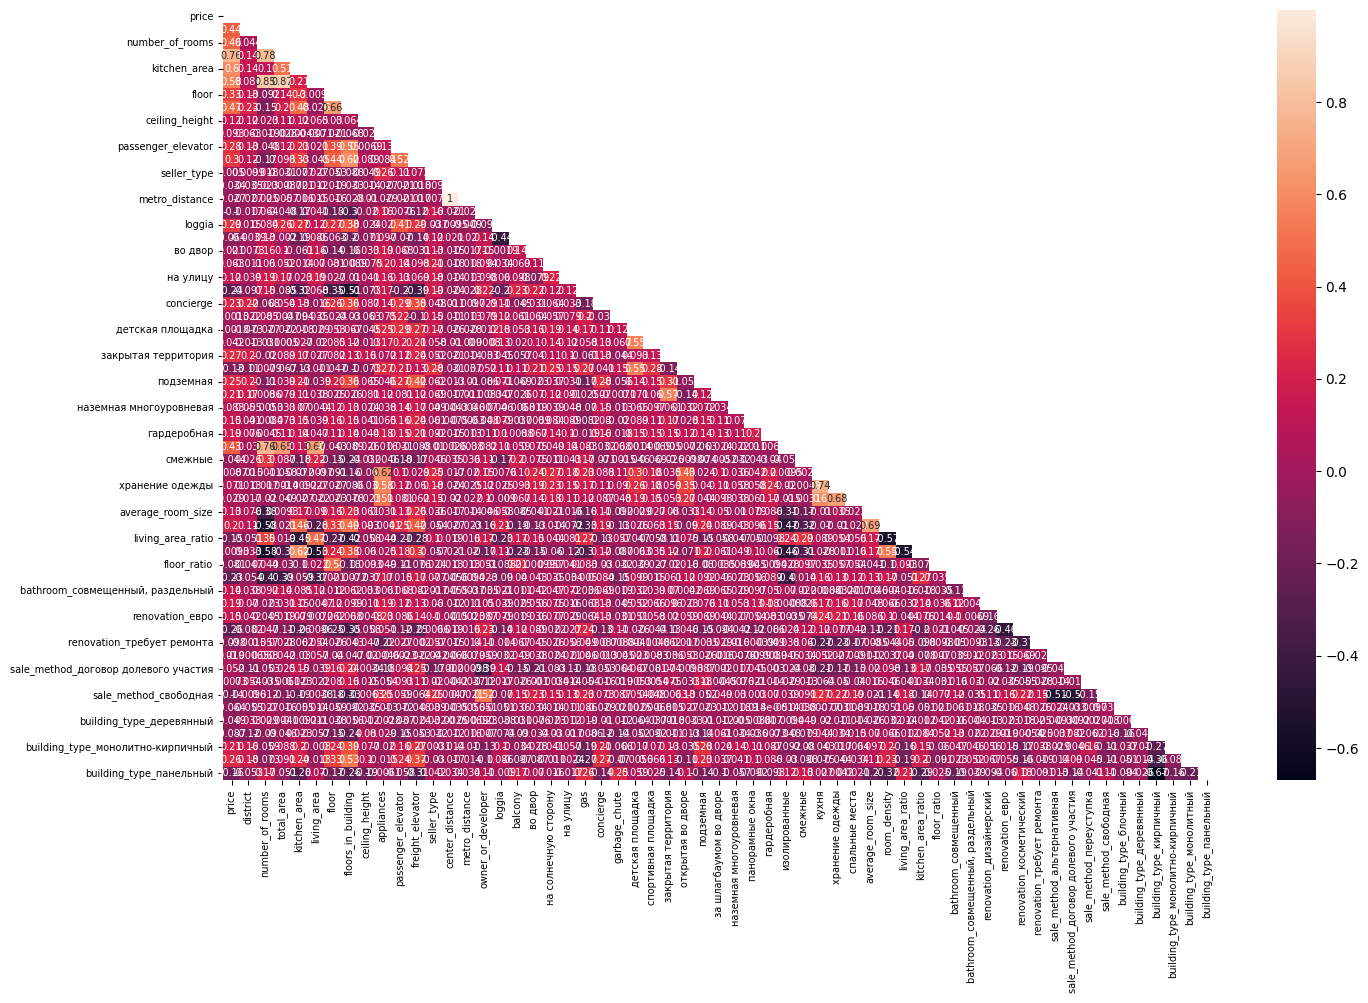

In [171]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), mask=mask, annot=True, annot_kws={"size": 7})
sns.set_style('white')
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.show()

### Смотрим на зависимост таргета от общей площади

<Axes: xlabel='total_area', ylabel='price'>

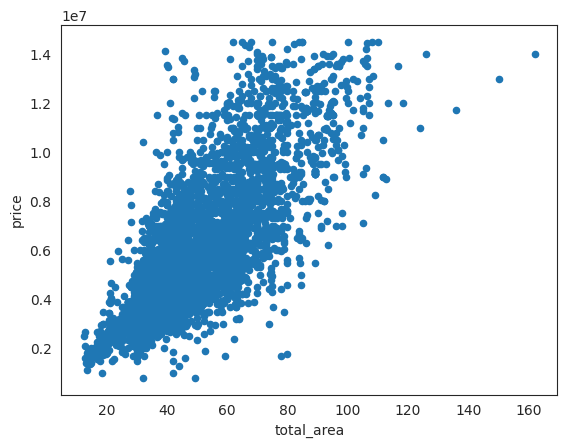

In [172]:
df.plot.scatter(x='total_area', y='price')

### Разделяем выборку на трейн и тест

In [173]:
X = df.drop('price', axis=1)
y =  df['price']

In [174]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Пробуем обучить модель на тестовых параметрах

In [175]:
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
from math import sqrt

model = XGBRegressor(
    objective = "reg:squarederror",
    n_estimators = 300,
    max_depth=6,
    learning_rate=0.1,
    random_seed=42,
    subsample = 0.8,
    colsample_bytree = 0.8
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:52:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### Смотрим на метрики нашей тестовой модели

In [176]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Делаем предсказания на тренировочных и тестовых данных
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Вычисляем метрики для тренировочного набора
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Для Adjusted R2
n_train = X_train.shape[0]  # количество наблюдений
p_train = X_train.shape[1]  # количество признаков
adjusted_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_train - 1)

# Вычисляем метрики для тестового набора
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Для Adjusted R2
n_test = X_test.shape[0]  # количество наблюдений
p_test = X_test.shape[1]  # количество признаков
adjusted_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_test - 1)

# Выводим результаты
print("Метрики на тренировочном наборе:")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAPE: {mape_train:.4f}")
print(f"R2: {r2_train:.4f}")
print(f"Adjusted R2: {adjusted_r2_train:.4f}")
print()
print("Метрики на тестовом наборе:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.4f}")
print(f"R2: {r2_test:.4f}")
print(f"Adjusted R2: {adjusted_r2_test:.4f}")

Метрики на тренировочном наборе:
RMSE: 167841.7662
MAPE: 0.0249
R2: 0.9961
Adjusted R2: 0.9961

Метрики на тестовом наборе:
RMSE: 874188.5361
MAPE: 0.0964
R2: 0.8956
Adjusted R2: 0.8885


### Оптимизируем гиперпараметры модели с помощью optuna

In [177]:
import optuna
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):
    # Определяем гиперпараметры для оптимизации
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_seed': 42,
        'importance_type': "gain"
    }
    
    # Создаем и обучаем модель
    model = XGBRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    
    # Делаем предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Вычисляем RMSE
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    
    # Соотношение ошибок (чем ближе к 1, тем лучше)
    ratio = max(rmse_train / rmse_test, rmse_test / rmse_train)
    
    # Комбинированная метрика
    combined_score = rmse_test * ratio
    
    return combined_score
    

# Оптимизация
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

# Лучшая модель
best_params = study.best_params
best_model = XGBRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Финальная оценка
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train RMSE: {rmse_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Difference: {abs(rmse_train - rmse_test):.4f}")

[I 2026-07-02 12:52:57,025] A new study created in memory with name: no-name-f1a361f0-e20b-4eff-bf0b-34801e8d190c


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:52:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2026-07-02 12:52:59,652] Trial 0 finished with value: 19361903.736074723 and parameters: {'n_estimators': 433, 'max_depth': 15, 'learning_rate': 0.055188112802166414, 'subsample': 0.9770964475811097, 'colsample_bytree': 0.6465968394718955, 'min_child_weight': 9, 'reg_alpha': 6.297335475841725, 'reg_lambda': 4.069546160013479}. Best is trial 0 with value: 19361903.736074723.


/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:52:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Par

...

[I 2026-07-02 12:53:54,786] Trial 95 finished with value: 1121849.7280860886 and parameters: {'n_estimators': 192, 'max_depth': 3, 'learning_rate': 0.08091757112066852, 'subsample': 0.5840579742477392, 'colsample_bytree': 0.846037018637436, 'min_child_weight': 2, 'reg_alpha': 3.7383091062984755, 'reg_lambda': 5.1364753118984705}. Best is trial 51 with value: 1079921.5400560114.


/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Par

[I 2026-07-02 12:53:55,020] Trial 96 finished with value: 1135044.3577114285 and parameters: {'n_estimators': 105, 'max_depth': 4, 'learning_rate': 0.09667831809911936, 'subsample': 0.6407985909830173, 'colsample_bytree': 0.9611589090533138, 'min_child_weight': 9, 'reg_alpha': 2.718096888101047, 'reg_lambda': 4.656868367051503}. Best is trial 51 with value: 1079921.5400560114.
[I 2026-07-02 12:53:55,205] Trial 97 finished with value: 1084494.9625631692 and parameters: {'n_estimators': 91, 'max_depth': 3, 'learning_rate': 0.07330181845251224, 'subsample': 0.9916876209491694, 'colsample_bytree': 0.9128639613715328, 'min_child_weight': 7, 'reg_alpha': 3.0439594355412405, 'reg_lambda': 5.814351090674471}. Best is trial 51 with value: 1079921.5400560114.


/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "random_seed" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_58/3007093141.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:53:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Par

[I 2026-07-02 12:53:55,410] Trial 98 finished with value: 1121648.0742687439 and parameters: {'n_estimators': 92, 'max_depth': 3, 'learning_rate': 0.06334945595725015, 'subsample': 0.9889322330656651, 'colsample_bytree': 0.915344135457877, 'min_child_weight': 7, 'reg_alpha': 3.0881619741196125, 'reg_lambda': 5.604802807388331}. Best is trial 51 with value: 1079921.5400560114.
[I 2026-07-02 12:53:56,078] Trial 99 finished with value: 2724496.670538155 and parameters: {'n_estimators': 122, 'max_depth': 10, 'learning_rate': 0.07160259193762555, 'subsample': 0.9585398586313907, 'colsample_bytree': 0.8715504901288741, 'min_child_weight': 8, 'reg_alpha': 3.5407662921549106, 'reg_lambda': 5.835244985581489}. Best is trial 51 with value: 1079921.5400560114.
Train RMSE: 834338.4442
Test RMSE: 949220.7634
Difference: 114882.3192


### Смотрим на метрики модели с лучшими гиперпараметрами

In [178]:
# Делаем предсказания на тренировочных и тестовых данных
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

# Вычисляем метрики для тренировочного набора
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred_best))
mape_train = mean_absolute_percentage_error(y_train, y_train_pred_best)
r2_train = r2_score(y_train, y_train_pred_best)

# Для Adjusted R2
n_train = X_train.shape[0]  # количество наблюдений
p_train = X_train.shape[1]  # количество признаков
adjusted_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p_train - 1)

# Вычисляем метрики для тестового набора
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred_best))
mape_test = mean_absolute_percentage_error(y_test, y_test_pred_best)
r2_test = r2_score(y_test, y_test_pred_best)

# Для Adjusted R2
n_test = X_test.shape[0]  # количество наблюдений
p_test = X_test.shape[1]  # количество признаков
adjusted_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p_test - 1)

# Выводим результаты
print("Метрики на тренировочном наборе:")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAPE: {mape_train:.4f}")
print(f"R2: {r2_train:.4f}")
print(f"Adjusted R2: {adjusted_r2_train:.4f}")
print()
print("Метрики на тестовом наборе:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAPE: {mape_test:.4f}")
print(f"R2: {r2_test:.4f}")
print(f"Adjusted R2: {adjusted_r2_test:.4f}")

Метрики на тренировочном наборе:
RMSE: 834338.4442
MAPE: 0.1078
R2: 0.9042
Adjusted R2: 0.9026

Метрики на тестовом наборе:
RMSE: 949220.7634
MAPE: 0.1092
R2: 0.8769
Adjusted R2: 0.8685


### Посмотрим на вклад фичей в итоговую модель

In [179]:
def plot_feature_importance(importance, names, model_type):
    
    #Create arrays from feature importance and feature names
    feature_importance = np.array(importance)
    feature_names = np.array(names)
    
    #Create a DataFrame using a Dictionary
    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)
    
    #Sort the DataFrame in order decreasing feature importance
    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    
    #Define size of bar plot
    plt.figure(figsize=(10,8))
    
    #Plot Searborn bar chart
    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])
    
    #Add chart labels
    plt.title(model_type + ' FEATURE IMPORTANCE')
    plt.xlabel('Feature importance')
    plt.ylabel('Feature names')

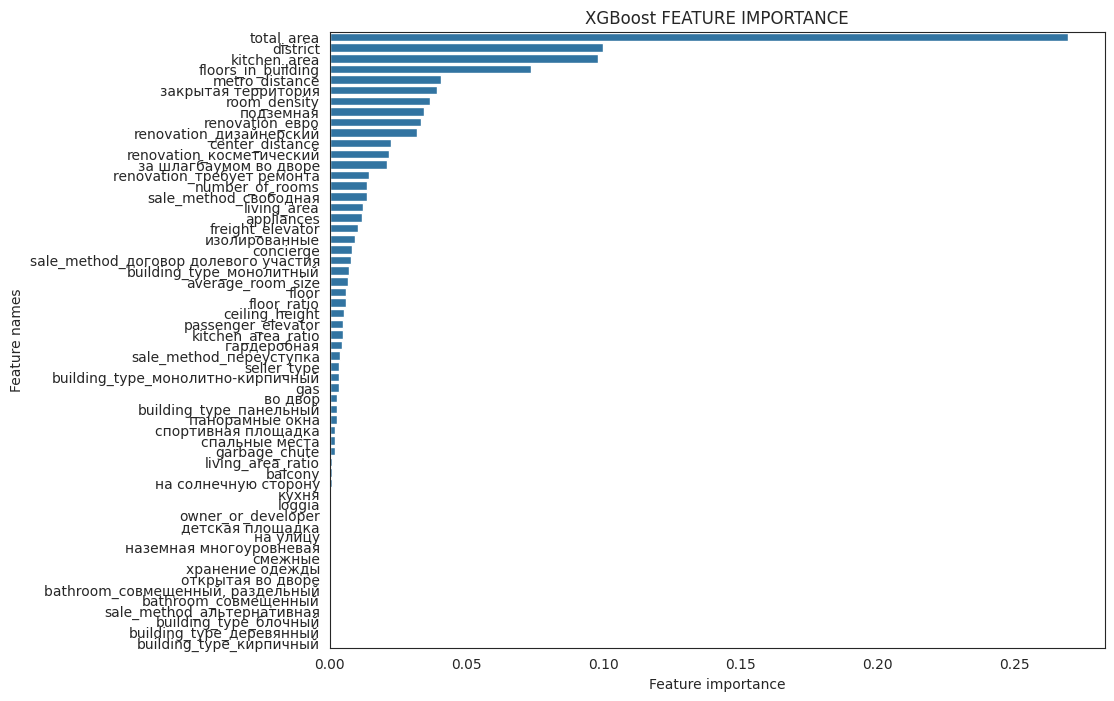

In [180]:
# Посмотрим на вклад каждой из фичей
plot_feature_importance(best_model.feature_importances_, X_train.columns, 'XGBoost')